In [8]:
import numpy as np
from itertools import zip_longest
class t_avg():

    def __init__(self,total_distance,num_repeaters):
        self.rng= np.random.default_rng()
        self.total_distance=total_distance
        self.num_repeaters=num_repeaters
        self.node_dist=total_distance/(2*num_repeaters+2)
        self.tau = 60e-3    
        F_em_single = 0.96
        pem = 4/3*(1-F_em_single)
        self.w_em=1-pem
        self.w_ms=0.99
        qfc_eff=0.3
        det_eff=0.9 #0.75
        coll_eff=0.69
        fiber_eff=np.power(10, -self.node_dist * 0.2 / 10) #0.3 in QCE simulation
        self.survive_prob=qfc_eff*det_eff*coll_eff*fiber_eff
        self.p=self.survive_prob**2/2
        self.DBSM_time = 119000/1e9
        self.BSM_time = 5000/1e9
        self.spin_echo_time = 36000/1e9  # applied after every 5 retries\n
        self.K=91
        self.photon_travel=self.node_dist*2/(2E5)
        self.init_time = 7220000/1e9
        self.retry_time = 75000/1e9  #not 175000/1e9
        self.T_attempt=self.photon_travel+self.retry_time+self.BSM_time
        self.ctrl_msg_time=(self.total_distance-self.node_dist)*2/(2E5) #From last bsm node to left end node(control node) and back
        self.end_msg_time=(2*self.total_distance-self.node_dist)/(2E5) #From last bsm node to left end node(control node) and back to right end node 
        #self.ctrl_msg_time=(self.total_distance/2-self.node_dist)*2/(2E5) #From 1st bsm node to centralized node and back
        #self.end_msg_time=(self.total_distance-self.node_dist)/(2E5) #From 1st bsm node to centralized node and back to end node
        num_link=num_repeaters+1
        if num_link%2==0:
            self.n_odd=int(num_link/2)
            self.n_even=int(num_link/2)
        else:
            self.n_odd=int(num_repeaters/2+1)
            self.n_even=int(num_repeaters/2)
        #print(self.p,self.n_odd,self.n_even)
    def Pr_M_leq_k(self,k,n):
        return (1-(1-self.p)**k)**n

    def Pr_X_leq_k(self,k,n):
        return 1-(1-self.p)**k
    
    def E_M_cond_leq_K(self,n):
        sum=0
        for k in range(self.K+1):
            sum+=k*(self.Pr_M_leq_k(k,n)-self.Pr_M_leq_k(k-1,n))
        return sum/self.Pr_M_leq_k(self.K,n)

    def E_X_cond_leq_K(self,n):
        sum=0
        for k in range(self.K+1):
            sum+=k*(self.Pr_X_leq_k(k,n)-self.Pr_X_leq_k(k-1,n))
        return sum/self.Pr_X_leq_k(self.K,n) #Check later

    def Tavg(self):
        #print(self.E_M_cond_leq_K(self.n_odd),self.E_X_cond_leq_K(self.n_odd),self.E_M_cond_leq_K(self.n_even))
        avg_waiting_odd=self.E_M_cond_leq_K(self.n_odd)-self.E_X_cond_leq_K(self.n_odd)+1+self.E_M_cond_leq_K(self.n_even)
        avg_waiting_even=self.E_M_cond_leq_K(self.n_even)-self.E_X_cond_leq_K(self.n_even)+1
        #avg_waiting_odd=self.E_M_cond_leq_K(self.n_odd)+1+self.E_M_cond_leq_K(self.n_even) #Do not minus E_X
        #avg_waiting_even=self.E_M_cond_leq_K(self.n_even)+1
        ctrl_msg_time=(self.total_distance/2-self.node_dist)*2/(2E5) #From 1st bsm node to centralized node and back
        end_msg_time=(self.total_distance-self.node_dist)/(2E5) #From 1st bsm node to centralized node and back to end node
        Tavg_odd=self.T_attempt*avg_waiting_odd+self.spin_echo_time*(avg_waiting_odd//5)+ctrl_msg_time
        #Tavg_even=self.T_attempt*avg_waiting_even+self.spin_echo_time*(avg_waiting_even//5)
        Tavg_even=self.T_attempt*avg_waiting_odd+self.spin_echo_time*(avg_waiting_odd//5) #Incorrect since DBSM is performed immediately after pBSM succeeds
        print("ctrl_msg_time",ctrl_msg_time,"end_msg_time",end_msg_time)
        print("avg_waiting_odd",avg_waiting_odd,"avg_waiting_even",avg_waiting_even,"Tavg_odd",Tavg_odd,"Tavg_even",Tavg_even,"spin echo time",f"{self.spin_echo_time*(avg_waiting_odd//5):.9g}")
        return Tavg_odd,Tavg_even
    
    def cal_F_total(self):
        #Here it is approximation with E[f(sigma)]~f(E[sigma]). We expect the fidelity is underestimated when T_attempt/tau is small.
        #t_avg_odd,t_avg_even=t_avg_instance.Tavg()
        #print("distance",distance,"n",n,"Tavg_odd",t_avg_odd,"Tavg_even",t_avg_even,"tau",tau)
        #sigma_odd = t_avg_odd / tau                   # std‑dev of phase θ
        #sigma_even = t_avg_even / tau
        #if n%2==1:
        #    theta_final = (1 + (np.exp(-(n+1)*(sigma_odd**2+sigma_even**2)/2)))/2 
        #else:
        #    theta_final = (1 + (np.exp(-((n+2)/2*(sigma_odd**2)+n/2*(sigma_even**2)))))/2 
        #print(distance,n,t_avg_instance.T_attempt,t_avg_instance.retry_time,t_avg_odd,t_avg_even,theta_final)
        #alpha = ((w_em ** (2*n+2)) * (w_ms ** (2*n)))
        
        #F_total = (alpha*theta_final + (1-alpha)*(1/4))
        #if n%2==1:
        #    theta_final = np.exp(-(n+1)*(sigma_odd**2+sigma_even**2)/2) 
        #else:
        #    theta_final = np.exp(-((n+2)/2*(sigma_odd**2)+n/2*(sigma_even**2)))

        theta_final=1
        lamb=self.w_ms ** (self.num_repeaters)
        F_total=1/4*(1+self.w_em ** (2*self.num_repeaters+2)*(2*lamb*theta_final+lamb**2))
        return F_total

    
    def Favg_MC(self,MC_shots):
        success_cnt=0
        odd_success_cnt=0
        total_cnt=0
        total_time=0
        total_attempt=0
        Esigma_ls=[]
        avg_retries_ls=[]
        #while total_cnt<MC_shots:
        while success_cnt<MC_shots:
            total_cnt+=1
            all_odd_success,required_attempts_odd=self.pBSM_MC(self.n_odd)
            
            if all_odd_success:
                odd_success_cnt+=1
                max_attempt_odd=max(required_attempts_odd)
                total_attempt+=max_attempt_odd
                all_even_success,required_attempts_even=self.pBSM_MC(self.n_even)
                
                if all_even_success:
                    avg_retries_ls.append(np.mean(np.concatenate([np.asarray(required_attempts_even),
                       np.asarray(required_attempts_odd)]))-1)
                    max_attempt_even=max(required_attempts_even)
                    total_attempt+=max_attempt_even
                    waiting_even = [max_attempt_even- v +1 for v in required_attempts_even]
                    waiting_odd = [max_attempt_odd - v +1 +max_attempt_even for v in required_attempts_odd]
                    #print("required_attempts_odd",required_attempts_odd,"required_attempts_even",required_attempts_even)
                    #print("waiting_odd",waiting_odd,"waiting_even",waiting_even)
                    #sum_Y_squared=2*sum(y**2 for y in waiting_even)+2*sum(y**2 for y in waiting_odd) #2 ions per link
                    #Esigma_ls.append(np.exp(-1/2*(2*self.T_attempt/self.tau)**2*sum_Y_squared))  
                    sum_deltaT_squared=self.cal_sum_deltaT_squared(required_attempts_even,required_attempts_odd)
                    Esigma_ls.append(np.exp(-1/2*(2/self.tau)**2*sum_deltaT_squared))                                
                    success_cnt+=1
                else:
                    total_attempt+=self.K
            else:
                total_attempt+=self.K
        Esigma=sum(Esigma_ls)/len(Esigma_ls)
        lamb=self.w_ms ** self.num_repeaters
        #print("n",self.num_repeaters,"lamb",lamb)
        #print("self.w_em ** (2*self.num_repeaters+2)",self.w_em ** (2*self.num_repeaters+2),"2*lamb*Esigma",2*lamb*Esigma,"lamb**2",lamb**2)
        F_avg=1/4*(1+self.w_em ** (2*self.num_repeaters+2)*(2*lamb*Esigma+lamb**2))
        avg_retries=np.mean(avg_retries_ls)
        total_time=total_cnt*self.init_time+total_attempt*self.T_attempt
        rate=1/total_time*success_cnt
        print("total_time",total_time,"rate",rate)
        #F_avg=1/4*(1+self.w_em ** (2*self.num_repeaters+2)*lamb**2*(1+2*Esigma)) #depol before MS gate
        return F_avg,rate,success_cnt,total_cnt,avg_retries
    
    def ion_to_link(self,j):
        #input j-th ion, output l-th pBSM link
        return int((j+1)//2)
        
    def cal_sum_deltaT_squared(self,required_attempts_even,required_attempts_odd):
        max_attempt_even=max(required_attempts_even)
        max_attempt_odd=max(required_attempts_odd)
        required_attempts = []
        for o, e in zip_longest(required_attempts_odd, required_attempts_even):
            required_attempts.append(o)
            if e is not None:
                required_attempts.append(e) 
            
        Y={} #T_attempt times
        Z={} #spin-echo times
        deltaT={}
        for j in range(1,2*self.num_repeaters+2+1):
            link_idx=self.ion_to_link(j)-1
            if j==1: #Left end node
                Y[j]=max_attempt_odd - required_attempts[link_idx] +1 +max_attempt_even
                Z[j]=(max_attempt_odd - required_attempts[link_idx] +1)//5+max_attempt_even//5
                deltaT[j]=self.ctrl_msg_time+self.end_msg_time
            elif j==2*self.num_repeaters+2: #Right end node
                if self.ion_to_link(j)%2==1:
                    #print(required_attempts_even,required_attempts_odd,required_attempts,"link_idx",link_idx,"self.num_repeaters",self.num_repeaters)
                    Y[j]=max_attempt_odd - required_attempts[link_idx] +1 +max_attempt_even
                    Z[j]=(max_attempt_odd - required_attempts[link_idx] +1)//5+max_attempt_even//5
                    deltaT[j]=self.ctrl_msg_time+self.end_msg_time
                else:
                    Y[j]=max_attempt_even - required_attempts[link_idx] +1 
                    Z[j]=(max_attempt_even - required_attempts[link_idx] +1)//5
                    deltaT[j]=self.end_msg_time
            elif self.ion_to_link(j)%2==1:
                if j%2==1: #odd link, left ion
                    Y[j]=max_attempt_odd - required_attempts[link_idx] +1 +required_attempts[link_idx-1]
                    Z[j]=(max_attempt_odd - required_attempts[link_idx] +1)//5+required_attempts[link_idx-1]//5
                    deltaT[j]=self.ctrl_msg_time
                else: #odd link, right ion
                    Y[j]=max_attempt_odd - required_attempts[link_idx] +1 +required_attempts[link_idx+1]
                    Z[j]=(max_attempt_odd - required_attempts[link_idx] +1)//5+required_attempts[link_idx+1]//5
                    deltaT[j]=self.ctrl_msg_time
            elif self.ion_to_link(j)%2==0: #DBSM immediately after even link is successful
                Y[j]=1
                Z[j]=0
                deltaT[j]=0
        #print("Y",Y,"required_attempts",required_attempts,required_attempts_odd,required_attempts_even)
        deltaT={k: Y[k]*self.T_attempt + Z[k]*self.spin_echo_time+ deltaT[k] for k in Y}
        return sum(value**2 for value in deltaT.values())                                
        
    def pBSM_MC(self,num_bsm):
        is_success=False
        required_attempts=self.rng.geometric(self.p,num_bsm)
        if all(v <= self.K for v in required_attempts):
            is_success=True
        return is_success,required_attempts
        
        
#qfc_eff=0.3
#det_eff=0.9 #0.75
#coll_eff=0.69
#num_repeaters=1
#total_distance=10
#node_dist=total_distance/(2*num_repeaters+2)
#fiber_eff= np.power(10, -node_dist * 0.3 / 10) #not 0.2
#survive_prob=qfc_eff*det_eff*coll_eff*fiber_eff
#p=survive_prob**2/2      
#print(p)
##t_avg1=t_avg(total_distance=50,num_repeaters=8) 
##print(t_avg1.Tavg())
#
#rng = np.random.default_rng()
##for _ in range(50):
##    print(rng.geometric(p=p))
#p, size = 0.35, 100
#
#rng = np.random.default_rng()
#
#sample = rng.geometric(p=p, size=size)
#print(sample)



survive prob 0.14798335012913363 pbsm prob 0.010949535957720878 success fraction per bsm 0.6328199765089517
total_time 24.048270000000002 rate 20.791516395981912
survive prob 0.15978874590748357 pbsm prob 0.012766221659343173 success fraction per bsm 0.6893863182239759
total_time 27.168806666666665 rate 18.403458279728152
survive prob 0.1660400497743168 pbsm prob 0.0137846490645288 success fraction per bsm 0.7172321683555025
total_time 36.34165 rate 13.75831862339767
survive prob 0.169907619372006 pbsm prob 0.014434299560331232 success fraction per bsm 0.7336897675509216
total_time 41.037859999999995 rate 12.183871186265563
survive prob 0.17253591905039423 pbsm prob 0.014884321681282094 success fraction per bsm 0.7445311094155747
total_time 55.17381666666667 rate 9.06226957291638
survive prob 0.1744381316039003 pbsm prob 0.015214330878729818 success fraction per bsm 0.7522027288622544
total_time 63.09577999999999 rate 7.92446024123959
survive prob 0.17587854125206753 pbsm prob 0.015466

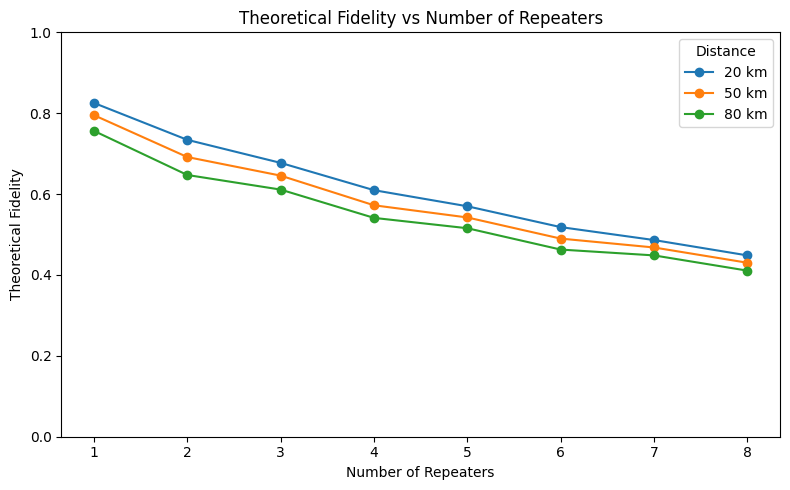

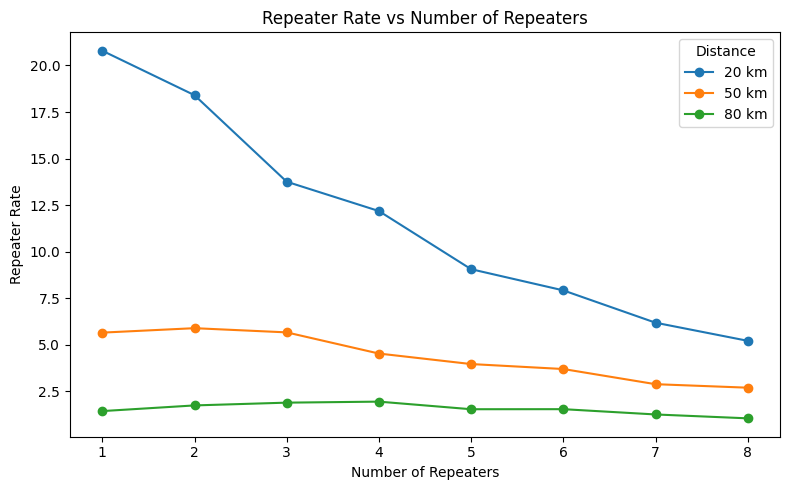

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


F_em_single = 0.96         # ion‑photon emission fidelity
p_ms  = 0.01               # MS‑gate depolarising probability
p_xz  = 0.001              # depolarising probability for X and Z gates
k_phase = 1                # dephasing factor (1 = independent phase)
tau = 60e-3                # coherence time [s]
MC_shots = 500 #5000            # Monte‑Carlo samples for phase noise
csv_file = "theo_repeater_rates.csv"


# df = pd.read_csv(csv_file)

# keep only rows with 1–8 repeaters and distance 10‑100 km
# mask = (df["num_repeaters"].between(1, 8)) & (df["distance"].between(10, 100))
# rows = df.loc[mask].copy()

def werner_fidelity(p, k):
    """F = (1 + (1-p)^k)/2"""
    return (1 + (1 - p) ** k) / 2

results = []
#for _, row in rows.iterrows():
#    n = int(row["num_repeaters"])
#    distance=int(row["distance"])
distance_ls=[20, 50, 80]
for distance in distance_ls:
    for n in range(1,9):
        t_avg_instance=t_avg(total_distance=distance,num_repeaters=n) 
        print("survive prob",t_avg_instance.survive_prob,"pbsm prob",t_avg_instance.p,"success fraction per bsm",1-(1-t_avg_instance.p)**91)
        #F_Z  = werner_fidelity(p_xz, n + 0.5)
        #F_X  = werner_fidelity(p_xz, 1.5 * n + 1)
        #F_MS = werner_fidelity(p_ms, n)
        #F_gate = F_Z * F_X * F_MS
        #pem = 4/3*(1-F_em_single)
        #F_em_chain = werner_fidelity(pem, 2*(n+1))
        #w_em=1# 1-pem
        #w_ms=1#0.9
        
        
       #seg_vals = []
       #for _ in range(MC_shots):
       #    theta = np.random.normal(0.0, sigma)
       #    F_seg = np.cos(k_phase * theta/2) ** 2          # one segment
       #    seg_vals.append(F_seg ** (n + 1))             # across n+1 segments
       #F_deph = np.mean(seg_vals)
       #F_total = F_em_chain * F_gate * F_deph
        F_total,rate,success_cnt,total_cnt,avg_retries=t_avg_instance.Favg_MC(MC_shots)
        #F_total=t_avg_instance.cal_F_total()
        success_ratio = (success_cnt / total_cnt) if total_cnt else float("nan")
    
        results.append(dict(
            distance=distance,
            rate=rate,
            num_repeaters=n,
            fidelity=F_total,
            success_ratio=success_ratio,
            success_cnt=int(success_cnt),
            total_cnt=int(total_cnt),
            avg_retries=avg_retries
        ))
    
output_df = pd.DataFrame(results)
output_df.to_csv("theo_fidelity_and_success.csv", index=False)

print("distance(km)  n  avg_retries   fidelity     rate    success_ratio   success_cnt  total_cnt")
for r in results:
    print(f"{r['distance']:>11}  {r['num_repeaters']:d}   {r['avg_retries']:.3f}         {r['fidelity']:.6f}    "
          f"{r['rate']:.6f}     {r['success_ratio']:.6f}      {r['success_cnt']:>6d}      {r['total_cnt']:>6d}")
#print("distance(km)  n  fidelity")
#for r in results:
#    print(f"{r['distance']:>11}  {r['num_repeaters']:d}  {r['fidelity']:.6f}")


plt.figure(figsize=(8, 5))
for dist in distance_ls:
    subset = output_df[output_df["distance"] == dist]
    plt.plot(subset["num_repeaters"], subset["fidelity"],
             marker='o', label=f"{dist} km")

plt.xlabel("Number of Repeaters")
plt.ylabel("Theoretical Fidelity")
plt.ylim(0, 1)
plt.title("Theoretical Fidelity vs Number of Repeaters")
plt.legend(title="Distance")
plt.tight_layout()
plt.savefig("theo_fidelity.png")
plt.show()

# --- Plot success_cnt/total_cnt on a separate plot ---
plt.figure(figsize=(8, 5))
for dist in distance_ls:
    subset = output_df[output_df["distance"] == dist]
    plt.plot(subset["num_repeaters"], subset["rate"], marker='o', label=f"{dist} km")
plt.xlabel("Number of Repeaters")
plt.ylabel("Repeater Rate")
#plt.ylim(0, 1)
plt.title("Repeater Rate vs Number of Repeaters")
plt.legend(title="Distance")
plt.tight_layout()
plt.savefig("theo_rate.png")
plt.show()

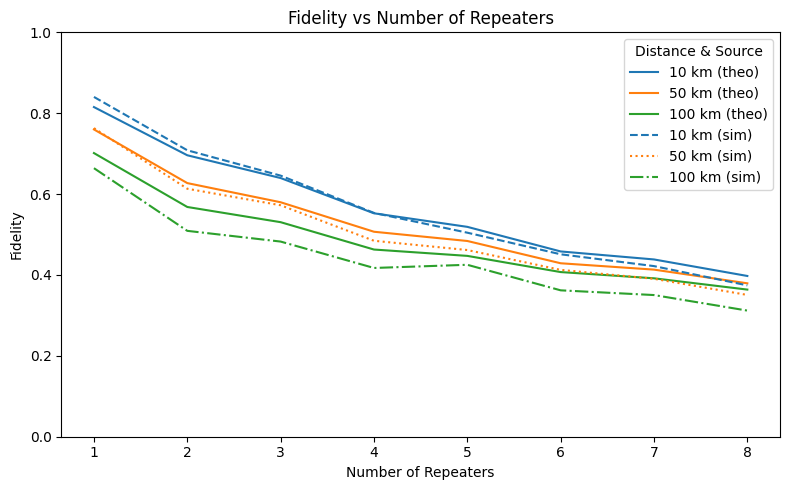

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

# Load both datasets
df_main = pd.read_csv("theo_fidelity.csv")
df_alt = pd.read_csv("60_fid_agg.csv")

# Define distances and line styles
distances = [10, 50, 100]
alt_linestyles = ['--', ':', '-.']  # dashed, dotted, dash-dot
colors = ['C0', 'C1', 'C2']         # consistent color palette for each distance

# Start plotting
plt.figure(figsize=(8, 5))

# Plot original lines (solid)
for i, dist in enumerate(distances):
    subset = df_main[df_main["distance"] == dist]
    plt.plot(subset["num_repeaters"], subset["fidelity"],
         linestyle='-', color=colors[i], label=f"{dist} km (theo)")

# Plot alternative lines (different style)
for i, dist in enumerate(distances):
    subset = df_alt[df_alt["distance"] == dist]
    plt.plot(subset["num_repeaters"], subset["fidelity"],
            linestyle=alt_linestyles[i], color=colors[i], label=f"{dist} km (sim)")

# Labels and formatting
plt.xlabel("Number of Repeaters")
plt.ylabel("Fidelity")
plt.ylim(0, 1)
plt.title("Fidelity vs Number of Repeaters")
plt.legend(title="Distance & Source")
plt.tight_layout()
# plt.savefig("fidelity_comparison_plot.png")
plt.show()
